# Part 1 - Application Area (Winter Weather Hazards)
- We are thinking of focusing on winter weather hazards and specific conditions that can cause or enhance these conditions
- It is interesting to explore due to different risks associated with these weather conditions. It is also interesting to closely monitor these storms out of personal interests. 
- It is useful to quantify this due to effects on travel conditions, school closures, power grids, energy usage, etc.
### Past Weather Event
- Late January Snow Storm of 2026
  
### Different parameters
- Temperature, snow depth, wind speed, precipitation type (freezing rain, sleet, snow, ice), visibility, wind chill, 10m wind gust

### Who Will Use
- General public who want information about upcoming and current winter weather hazards
- School districts and universities for school closure decisions

### Hazard Index (preliminary)
- 0: No hazard
- 1: Little to no impact
- 2: Slight impacts
- 3: Moderate impacts
- 4: Major impacts
- 5: Extreme impacts

### Weighting of Variables (preliminary)
- Visibility, wind chill, ice accumulation, snow depth, wind speed will all be important variables to be weighted heavily in our index

# Part 2 - Relevant Model Data and Surface Observations
Data taken from Jan 23 to Jan 27 2026

In [13]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask

## Testing Data

In [78]:
run = pd.Timestamp("2026-01-23-00")

In [79]:
# model run Jan 23 2026
#H = Herbie(run, model="ifs", product="oper", fxx=6, save_dir='./courses/meteo473/sp26/group6/data/', overwrite=True)

In [80]:
#H.inventory()

In [81]:
# specific parameters: geopotential height, 2m temp, snow depth (m), wind chill, wind speed, u and v components, visibility, total precipitation
#
ss = r":(gh|t|u|v|2t|sd|10fg|sp|ws|tp|ptype|tprate):" 

In [82]:
#H.inventory().param.unique()

In [83]:
#H.inventory(ss)

In [84]:
#fp = H.download(ss)

In [85]:
#ds = xr.open_dataset(fp)
#ds

## Saving Data (MP)

In [2]:
run = pd.Timestamp("2026-01-23-00")
H = FastHerbie([run], model="ifs", product="oper", fxx=np.arange(0,102,6).tolist(), save_dir='./data/', overwrite=True)

In [3]:
#Note (from Luke) - we had to load 2m temperature separately because the 'height above ground' coordinate was giving issues. 
ss1 = r":(2t):"
ss2 = r":(gh|t|u|v|sd|10fg|sp|ws|tp|ptype|tprate):" 
H.inventory(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

,grib_message,start_byte,end_byte,range,reference_time,valid_time,step,param,levelist,levtype,number,domain,expver,class,type,stream,search_this,FILE
0,8,3841534,4871060,3841534-4871060,2026-01-23,2026-01-23,0 days,ptype,NaN,sfc,NaN,g,0001,od,fc,oper,:ptype:sfc:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
1,11,5703885,6384783,5703885-6384783,2026-01-23,2026-01-23,0 days,tprate,NaN,sfc,NaN,g,0001,od,fc,oper,:tprate:sfc:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
2,17,8320627,8749643,8320627-8749643,2026-01-23,2026-01-23,0 days,gh,100,pl,NaN,g,0001,od,fc,oper,:gh:100:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
3,19,8749867,9485485,8749867-9485485,2026-01-23,2026-01-23,0 days,v,500,pl,NaN,g,0001,od,fc,oper,:v:500:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
4,24,13202368,13913549,13202368-13913549,2026-01-23,2026-01-23,0 days,u,500,pl,NaN,g,0001,od,fc,oper,:u:500:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,154,122150785,122584169,122150785-122584169,2026-01-23,2026-01-27,4 days,gh,150,pl,NaN,g,0001,od,fc,oper,:gh:150:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
981,155,122584169,123123438,122584169-123123438,2026-01-23,2026-01-27,4 days,sp,NaN,sfc,NaN,g,0001,od,fc,oper,:sp:sfc:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
982,156,123123438,123817050,123123438-123817050,2026-01-23,2026-01-27,4 days,u,700,pl,NaN,g,0001,od,fc,oper,:u:700:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
983,158,125163568,125877302,125163568-125877302,2026-01-23,2026-01-27,4 days,v,700,pl,NaN,g,0001,od,fc,oper,:v:700:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...


In [4]:
filepath1 = H.download(ss1)
filepath2 = H.download(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [5]:
filepath1

[PosixPath('data/ifs/20260123/subset_a9b297da__20260123000000-6h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9782664__20260123000000-54h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a90ec02c__20260123000000-36h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a90e2f9a__20260123000000-24h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a91c2f9a__20260123000000-48h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9ef0171__20260123000000-0h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9895c75__20260123000000-18h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9605c75__20260123000000-30h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9052664__20260123000000-84h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9122664__20260123000000-12h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9f15f18__20260123000000-72h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9432f9a__20260123000000-60h-oper-fc.grib2'),
 Posix

In [6]:
ds1 = xr.open_mfdataset(filepath1, combine='nested', concat_dim='valid_time')
ds2 = xr.open_mfdataset(filepath2, combine='nested', concat_dim='valid_time', coords = 'minimal', compat = 'override')

Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a9b297da__20260123000000-6h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a9782664__20260123000000-54h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a90ec02c__20260123000000-36h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a90e2f9a__20260123000000-24h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a91c2f9a__20260123000000-48h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a9ef0171__20260123000000-0h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp2

In [7]:
ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')

/tmp/ipykernel_1607066/4260339120.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')


In [8]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:            (latitude: 721, longitude: 1440, valid_time: 17,
                        isobaricInhPa: 13)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B ...
Data variables:
    t2m                (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    fg10               (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sd                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ptype              (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tprate             (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sp                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-25T16:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [9]:
ds = ds.sortby('valid_time')
ds

<xarray.Dataset> Size: 4GB
Dimensions:            (latitude: 721, longitude: 1440, valid_time: 17,
                        isobaricInhPa: 13)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B ...
Data variables:
    t2m                (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    fg10               (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sd                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ptype              (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tprate             (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sp                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-25T16:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [10]:
ds = ds.sel(latitude=slice(60,20), longitude=slice(-130,-60))
ds

<xarray.Dataset> Size: 182MB
Dimensions:            (latitude: 161, longitude: 281, valid_time: 17,
                        isobaricInhPa: 13)
Coordinates:
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B ...
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    fg10               (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 40MB dask.array<chunksize=(1, 13, 161, 281), meta=np.ndarray>
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB dask.array<chunksize=(1, 13, 161, 281), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB dask.array<chunksize=(1, 13, 161, 281), meta=np.ndarray>
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB dask.array<chunksize=(1, 13, 161, 281), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    sd                 (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    ptype              (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    tprate             (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    sp                 (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-25T16:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [12]:
fname = f'ecmwf_update5.nc'
ds.to_netcdf(fname)

PermissionError: [Errno 13] Permission denied: '/courses/meteo473/sp26/473_sp26_group6/ecmwf_update4.nc'

# Part 3 - Creating Initial Plots
- Will be using wind chill as derived variable (could not find it in dataset)
- Plots will be 2 meter temperature, wind chill, precipitation type (ptype) (custom color map), 10m wind gust (fg10), snow depth (sd)
- Time step is 18z Jan 25

In [14]:
ds_test = xr.open_dataset(f'ecmwf_update5.nc').load()
ds_test

sh: 1: getfattr: not found


<xarray.Dataset> Size: 182MB
Dimensions:            (valid_time: 17, latitude: 161, longitude: 281,
                        isobaricInhPa: 13)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB 256.7 .....
    fg10               (valid_time, latitude, longitude) float32 3MB 0.0 ... nan
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    sd                 (valid_time, latitude, longitude) float32 3MB 0.1411 ....
    tp                 (valid_time, latitude, longitude) float32 3MB 0.0 ... ...
    ptype              (valid_time, latitude, longitude) float32 3MB 0.0 ... 1.0
    tprate             (valid_time, latitude, longitude) float32 3MB 0.0 ... ...
    sp                 (valid_time, latitude, longitude) float32 3MB 8.972e+0...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-25T16:25 GRIB to CDM+CF via cfgrib-0.9.1...

In [15]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm

In [16]:
# Define Basemap
def GeoAxes():
    fig = plt.figure(figsize=(12,9))
    ax = plt.axes(projection=ccrs.LambertConformal())
    ax.set_extent([-120,-70,25,50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
    ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'))
    return fig, ax  

In [17]:
# Defining Time
time_index = 11
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds.valid_time.values[0])
valid_time_d = pd.to_datetime(ds.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")

In [18]:
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

# 2m Temperature Plot (MP)

Text(0.5, 1.0, '2m Temperature (°F)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

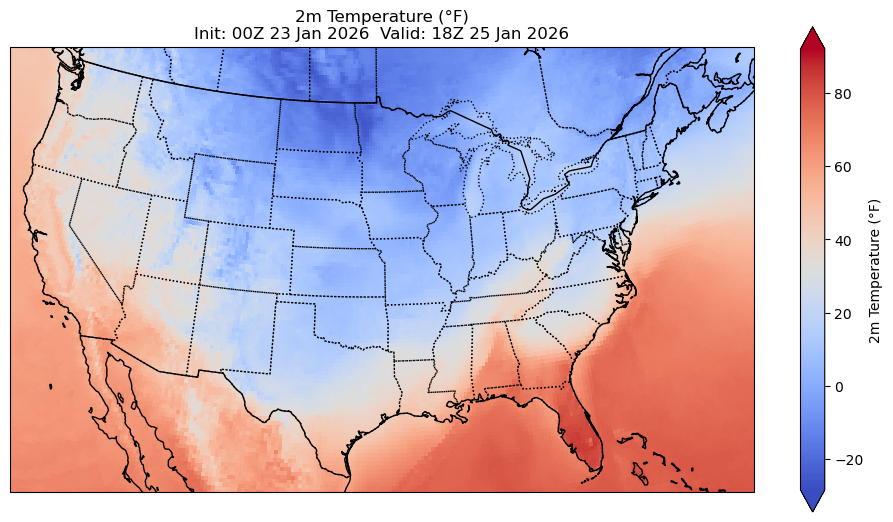

In [19]:
fig, ax = GeoAxes()

t2m = ds_test['t2m'].isel(valid_time=time_index)
cs = ax.pcolormesh(lon, lat, (t2m-273.15)*1.8+32, transform=dataproj, cmap='coolwarm')
plt.colorbar(cs, label = '2m Temperature (°F)', extend = 'both', shrink=0.7)
ax.set_title(f"2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}")

Text(0.5, 1.0, '10m Wind Gust (kt)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

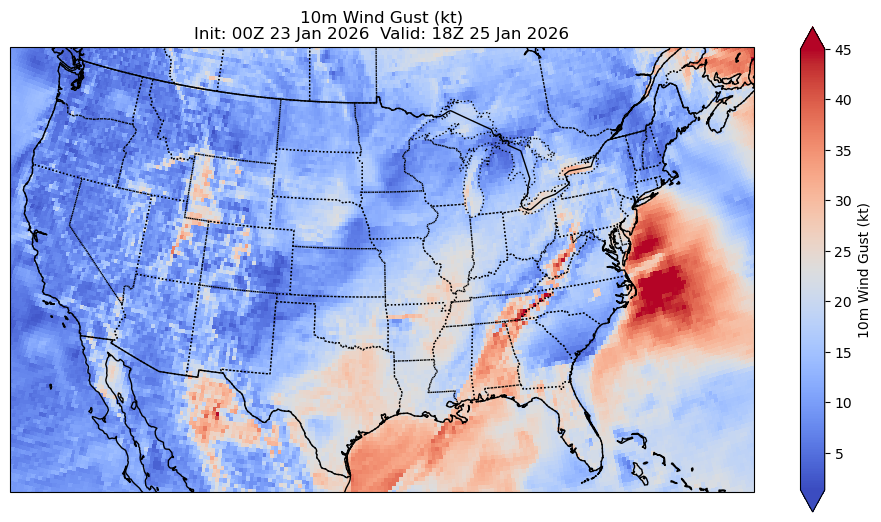

In [51]:
fig, ax = GeoAxes()
wgust = ds_test['fg10'].isel(valid_time=time_index)
cs = ax.pcolormesh(lon, lat, wgust*1.94384449, transform=dataproj, vmax=45, cmap='coolwarm')
plt.colorbar(cs, label = '10m Wind Gust (kt)', extend = 'both', shrink=0.7)
ax.set_title(f"10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}")

Text(0.5, 1.0, 'Snow Depth (in)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

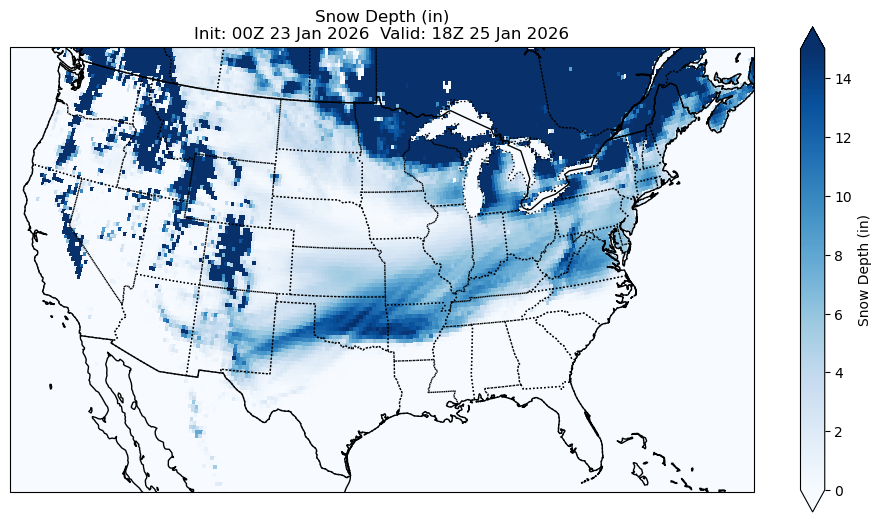

In [52]:
#Convert and plot snow depth in inches from the snow depth water equvialent variable in meters assuming a 10:1 snow to liquid ratio.
fig, ax = GeoAxes()
snow_depth = ds_test['sd'].isel(valid_time=time_index)
cs = ax.pcolormesh(lon, lat, snow_depth*39.3700787*10, transform=dataproj, vmax=15, cmap='Blues')
plt.colorbar(cs, label = 'Snow Depth (in)', extend = 'both', shrink=0.7)
ax.set_title(f"Snow Depth (in)\nInit: {init_str}  Valid: {valid_str}")

In [53]:
# Note: this may overestimate snow in areas that are forecast to see mixed precipitation which will lower snow-liquid ratios.
# This also includes previous high snow cover in the Rockies, Cascades, and Canada (the dark blue colors).

# Precipitation Type Plot (MP)
- Custom color map with different values being defined as different precipitation types

In [23]:
# custom color map (used ChatGPT to help with formatting and inputs for colors, values, and cmap)
ptype_colors = [
    "white",        # 0 = No precipitation
    "green",        # 1 = Rain
    "red",          # 3 = Freezing rain
    "blue",         # 5 = Snow
    "cyan",         # 6 = Wet snow
    "purple",       # 7 = Rain/Snow mix
    "orange",       # 8 = Ice pellets
    "pink"          # 12 = Freezing drizzle
]

ptype_values = [0, 1, 3, 5, 6, 7, 8, 12]

cmap = ListedColormap(ptype_colors)
norm = BoundaryNorm(ptype_values + [13], cmap.N)

Text(0.5, 1.0, 'Precipitation Type \nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

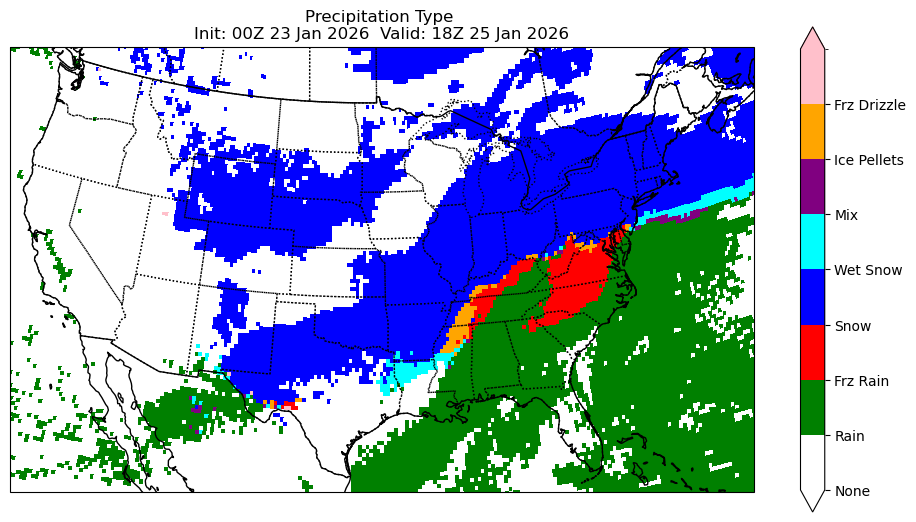

In [24]:
fig, ax = GeoAxes()

ptype = ds_test['ptype'].isel(valid_time=time_index)
mesh = ax.pcolormesh(
    lon, lat, ptype, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(mesh, ax=ax, extend = 'both', shrink=0.7)
cbar.set_ticks(ptype_values)
cbar.set_ticklabels([
    "None", "Rain", "Frz Rain", "Snow",
    "Wet Snow", "Mix", "Ice Pellets", "Frz Drizzle"])
ax.set_title(f"Precipitation Type \nInit: {init_str}  Valid: {valid_str}")

# Derived Variable (Wind Chill) Plot (MP)
- using 1000 hpa wind speed

In [25]:
# deriving wind whill
u_wind = ds_test['u'].isel(isobaricInhPa=0).isel(valid_time=time_index)
v_wind = ds_test['v'].isel(isobaricInhPa=0).isel(valid_time=time_index)
# converting t2m to F
t2m_F = (t2m - 273.15) * 9/5 + 32
# calculating total wind
V_ms = np.sqrt(u_wind**2 + v_wind**2)
V_mph = V_ms * 2.237
# applying WC formula
wind_chill = (35.74 + 0.6215 * t2m_F - 35.75 * (V_mph ** 0.16) + 0.4275 * t2m_F * (V_mph ** 0.16))
# masking invalid conditions 
wind_chill = np.where((t2m_F <= 50) & (V_mph >= 3), wind_chill, np.nan)

Text(0.5, 1.0, 'Wind Chill (°F)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

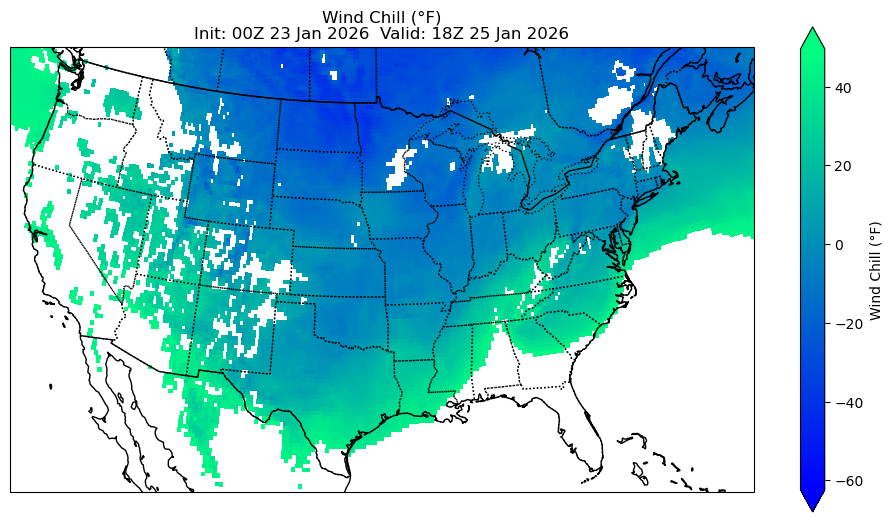

In [26]:
# creating plot
fig, ax = GeoAxes()

cs = ax.pcolormesh(lon, lat, wind_chill, transform=dataproj, cmap='winter')
plt.colorbar(cs, label = 'Wind Chill (°F)', extend='both', shrink=0.7)
ax.set_title(f"Wind Chill (°F)\nInit: {init_str}  Valid: {valid_str}")

## Creating Hazard Plot for Wind Chill

In [27]:
# Define bounds (°F) Used ChatGPT again for defining colors, bounds, values
bounds = [-100, -20, -10, 0, 10, 20, 30, 40, 100]

# NWS-style colors (cold → warm)
colors = [
    "#4B0082",  # Extreme danger (deep purple)
    "#8B0000",  # Very dangerous (dark red)
    "#FF0000",  # Danger (red)
    "#FF8C00",  # Bitter cold (orange)
    "#FFD700",  # Very cold (yellow)
    "#ADFF2F",  # Cold (yellow-green)
    "#00CED1",  # Cool (teal)
    "#D3D3D3"   # No risk (light gray)
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

Text(0.5, 1.0, 'Wind Chill Hazard (°F) (Lower Values More Hazardous)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

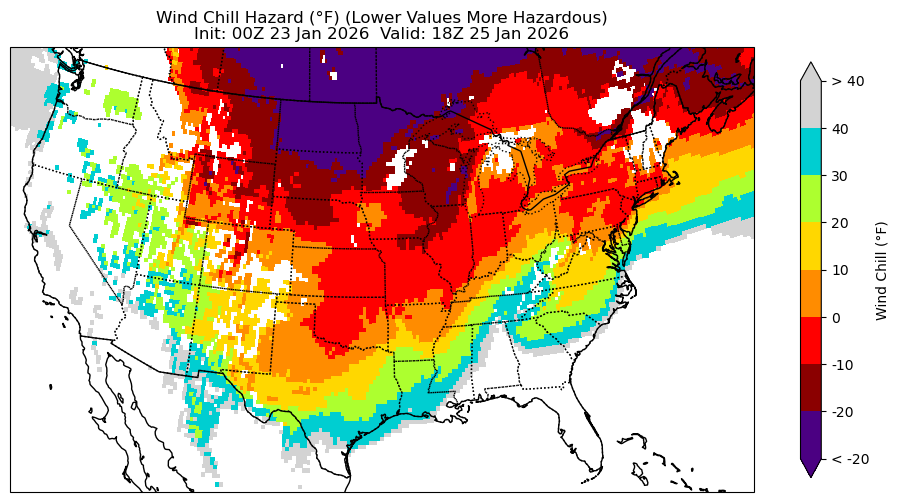

In [28]:
fig, ax = GeoAxes()

mesh = ax.pcolormesh(lon, lat, wind_chill, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

cbar = plt.colorbar(mesh, ax=ax, extend='both', shrink=0.6)
cbar.set_label("Wind Chill (°F)")
cbar.set_ticks(bounds)
cbar.set_ticklabels(["< -20", "-20", "-10", "0", "10", "20", "30", "40", "> 40"])
ax.set_title(f"Wind Chill Hazard (°F) (Lower Values More Hazardous)\nInit: {init_str}  Valid: {valid_str}")